# Classificador Variacional Quântico com Iris Dataset

Este notebook implementa e compara um classificador quântico variacional (VQC) com um classificador clássico (SVM) usando o conjunto de dados Iris.

## 1. Importando bibliotecas necessárias

In [3]:
# Bibliotecas básicas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import sklearn

# Bibliotecas de machine learning
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, auc

# Configurações de visualização
plt.style.use('default')
sns.set_theme(style="whitegrid")

# Verificando versões das bibliotecas
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")

NumPy version: 2.2.6
Pandas version: 2.2.3
Scikit-learn version: 1.6.1


In [4]:
# Importando bibliotecas do Qiskit
try:
    import qiskit
    import qiskit_machine_learning
    from qiskit import Aer
    from qiskit.circuit.library import ZFeatureMap, RealAmplitudes
    from qiskit_machine_learning.algorithms import VQC
    from qiskit.algorithms.optimizers import COBYLA
    
    print(f"Qiskit version: {qiskit.__version__}")
    print(f"Qiskit Machine Learning version: {qiskit_machine_learning.__version__}")
except ImportError as e:
    print(f"Error importing Qiskit libraries: {e}")
    print("Please make sure you have installed qiskit and qiskit-machine-learning")

Qiskit version: 0.22.4
Qiskit Machine Learning version: 0.5.0


## 2. Carregando e preparando os dados

In [5]:
# Carregando o dataset Iris
iris = load_iris()
X = iris.data
y = iris.target

# Informações sobre o dataset
print(f"Dataset shape: {X.shape}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Classes: {iris.target_names}")
print(f"Features: {iris.feature_names}")

# Normalizando os dados para o intervalo [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))
features = scaler.fit_transform(X)
labels = y

# Criando um DataFrame para visualização
iris_df = pd.DataFrame(X, columns=iris.feature_names)
iris_df['species'] = pd.Categorical.from_codes(y, iris.target_names)

Dataset shape: (150, 4)
Number of classes: 3
Classes: ['setosa' 'versicolor' 'virginica']
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


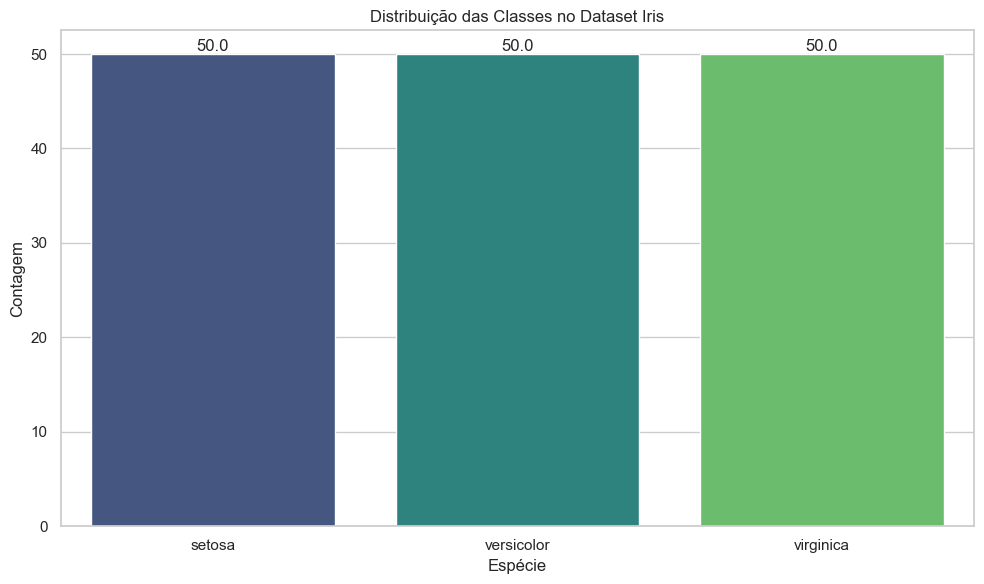

In [6]:
# Visualizando a distribuição das classes
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='species', hue='species', data=iris_df, palette='viridis', legend=False)

plt.title('Distribuição das Classes no Dataset Iris')
plt.xlabel('Espécie')
plt.ylabel('Contagem')

# Adicionando rótulos de contagem
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()

<Figure size 1200x1000 with 0 Axes>

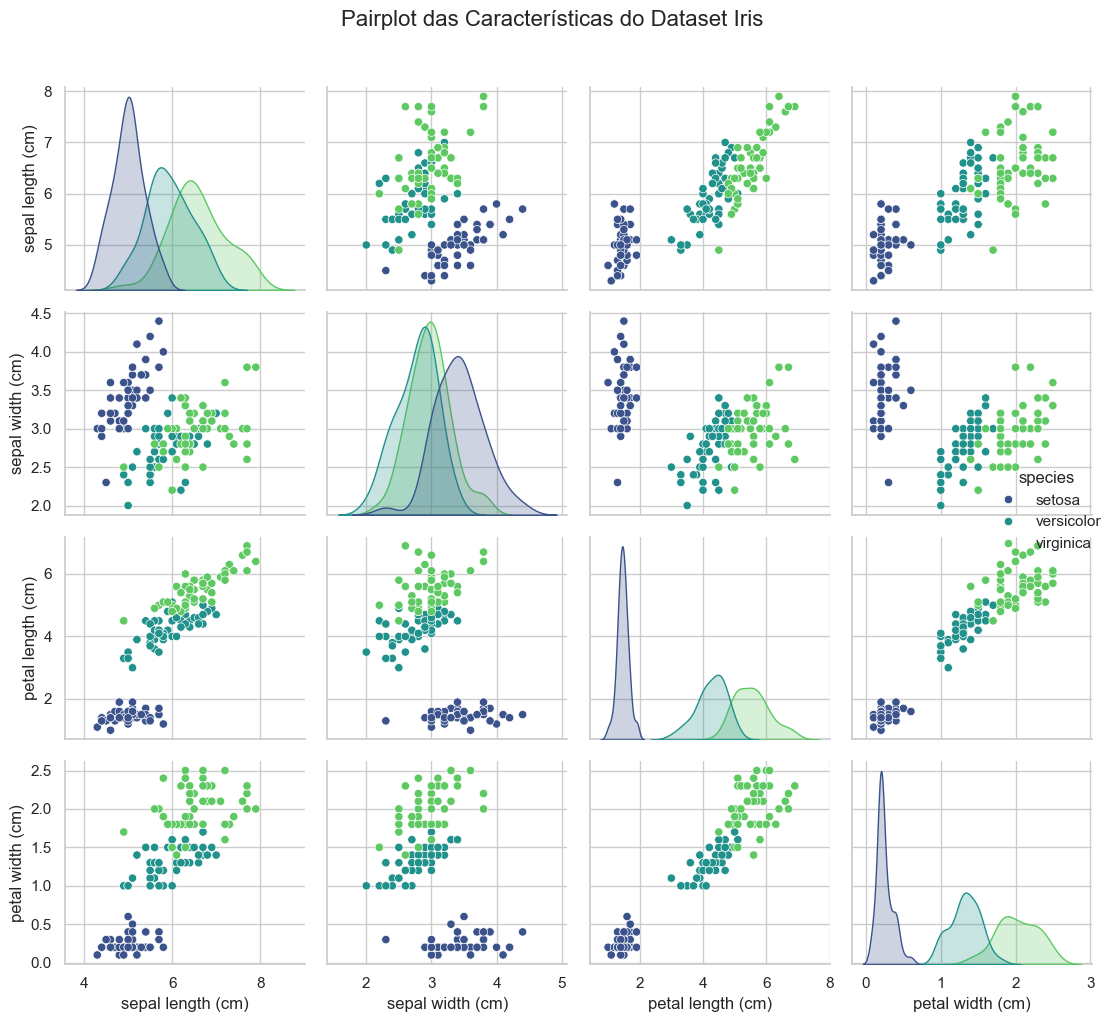

In [7]:
# Visualizando os dados com pairplot
plt.figure(figsize=(12, 10))
sns.pairplot(iris_df, hue='species', height=2.5, palette='viridis')
plt.suptitle('Pairplot das Características do Dataset Iris', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

## 3. Divisão dos dados em treino e teste

In [8]:
# Divisão dos dados com seed fixo para reprodutibilidade
TTS_seed = 123
train_features, test_features, train_labels, test_labels = train_test_split(
    features, labels, random_state=TTS_seed, test_size=0.25, stratify=labels
)

print(f"Tamanho do conjunto de treino: {train_features.shape[0]} amostras")
print(f"Tamanho do conjunto de teste: {test_features.shape[0]} amostras")

Tamanho do conjunto de treino: 112 amostras
Tamanho do conjunto de teste: 38 amostras


## 4. Implementação do Classificador Clássico (SVM)

In [9]:
def train_classic_classifier():
    """Treina um classificador SVM clássico usando a estratégia One-vs-Rest."""
    svc_classico = OneVsRestClassifier(SVC(kernel="linear", max_iter=100, probability=True))
    svc_classico.fit(train_features, train_labels)
    return svc_classico

## 5. Implementação do Classificador Quântico (VQC)

In [12]:
# Número de features (4) define o número de qubits
num_features = features.shape[1]

# Codificação usando ZFeatureMap (circuito de evolução de Pauli de primeira ordem, sem emaranhamento)
feature_map = ZFeatureMap(feature_dimension=num_features, reps=1)

# Visualizando o circuito de feature map
try:
    feature_map.decompose().draw(output="mpl", fold=30)
except Exception as e:
    print(f"Erro ao desenhar o circuito: {e}")
    print("Continuando sem visualização do circuito...")

In [13]:
# Criando o ansatz (circuito variacional)
var_circuit = RealAmplitudes(num_qubits=num_features, reps=2)

# Visualizando o ansatz
try:
    var_circuit.decompose().draw(output="mpl", fold=30)
except Exception as e:
    print(f"Erro ao desenhar o circuito: {e}")
    print("Continuando sem visualização do circuito...")

In [12]:
# Configurando o otimizador
optimizer = COBYLA(maxiter=100)

# Função de callback para monitorar o progresso da otimização
callback_values = []
def callback_func(weights, obj_func_eval):
    callback_values.append(obj_func_eval)

In [14]:
def train_quantum_classifier():
    """Treina um classificador quântico variacional (VQC)."""
    # Configurando o backend do simulador
    backend = Aer.get_backend('aer_simulator_statevector')
    
    # Verificando a versão do scikit-learn para compatibilidade
    from packaging import version
    sklearn_version = version.parse(sklearn.__version__)
    
    # Criando o classificador quântico variacional
    # Ajustando parâmetros com base na versão do scikit-learn
    if sklearn_version >= version.parse('1.2.0'):
        # Para scikit-learn >= 1.2.0, usamos sparse_output
        vqc = VQC(
            feature_map=feature_map,
            ansatz=var_circuit,
            optimizer=optimizer,
            callback=callback_func,
            quantum_instance=backend,
            one_hot_encoder_params={'sparse_output': False}
        )
    else:
        # Para scikit-learn < 1.2.0, usamos sparse
        vqc = VQC(
            feature_map=feature_map,
            ansatz=var_circuit,
            optimizer=optimizer,
            callback=callback_func,
            quantum_instance=backend,
            one_hot_encoder_params={'sparse': False}
        )
    
    # Treinando o modelo
    vqc.fit(train_features, train_labels)
    return vqc

## 6. Função para calcular métricas

In [15]:
# Função para calcular a especificidade
def specificity_score(y_true, y_pred):
    """Calcula a especificidade média para classificação multiclasse."""
    cm = confusion_matrix(y_true, y_pred)
    specificities = []
    
    for i in range(len(cm)):
        # Verdadeiros negativos são todos os elementos exceto os da linha e coluna i
        true_negatives = np.sum(np.delete(np.delete(cm, i, axis=0), i, axis=1))
        # Falsos positivos são os elementos da coluna i exceto o elemento (i,i)
        false_positives = np.sum(cm[:, i]) - cm[i, i]
        
        if true_negatives + false_positives > 0:
            specificities.append(true_negatives / (true_negatives + false_positives))
        else:
            specificities.append(0)
    
    return np.mean(specificities)

## 7. Treinamento e avaliação dos modelos

In [16]:
# Treinando o classificador clássico e medindo o tempo
print("Treinando o classificador clássico...")
start_time = time.time()
classic_classifier = train_classic_classifier()
time_classic = time.time() - start_time

# Fazendo previsões com o classificador clássico
train_predicts_classic = classic_classifier.predict(train_features)
test_predicts_classic = classic_classifier.predict(test_features)

print(f"Classificador clássico treinado em {time_classic:.4f} segundos.")

Treinando o classificador clássico...
Classificador clássico treinado em 0.0152 segundos.


In [17]:
print("Métricas para o classificador clássico:")
print("Tempo de treinamento:", time_classic, "segundos")
print("\nRelatório de classificação (treino):")
print(classification_report(train_labels, train_predicts_classic, digits=4, target_names=iris.target_names))
print("Acurácia (Treino):", accuracy_score(train_labels, train_predicts_classic))
print("Especificidade (Treino):", specificity_score(train_labels, train_predicts_classic))
print("\nRelatório de classificação (teste):")
print(classification_report(test_labels, test_predicts_classic, digits=4, target_names=iris.target_names))
print("Acurácia (Teste):", accuracy_score(test_labels, test_predicts_classic))
print("Especificidade (Teste):", specificity_score(test_labels, test_predicts_classic))

Métricas para o classificador clássico:
Tempo de treinamento: 0.015159845352172852 segundos

Relatório de classificação (treino):
              precision    recall  f1-score   support

      setosa     0.9744    1.0000    0.9870        38
  versicolor     1.0000    0.5946    0.7458        37
   virginica     0.7255    1.0000    0.8409        37

    accuracy                         0.8661       112
   macro avg     0.8999    0.8649    0.8579       112
weighted avg     0.9006    0.8661    0.8590       112

Acurácia (Treino): 0.8660714285714286
Especificidade (Treino): 0.9332732732732733

Relatório de classificação (teste):
              precision    recall  f1-score   support

      setosa     0.9231    1.0000    0.9600        12
  versicolor     1.0000    0.3077    0.4706        13
   virginica     0.6190    1.0000    0.7647        13

    accuracy                         0.7632        38
   macro avg     0.8474    0.7692    0.7318        38
weighted avg     0.8454    0.7632    0.7258 

In [18]:
# Treinando o classificador quântico e medindo o tempo
print("Treinando o classificador quântico (isso pode levar alguns minutos)...")
start_time = time.time()
try:
    # Verificar se o pacote packaging está instalado
    try:
        import packaging
    except ImportError:
        !pip install packaging
        import packaging
        
    quantum_classifier = train_quantum_classifier()
    time_quantum = time.time() - start_time
    
    # Fazendo previsões com o classificador quântico
    train_predicts_quantum = quantum_classifier.predict(train_features)
    test_predicts_quantum = quantum_classifier.predict(test_features)
    
    print(f"Classificador quântico treinado em {time_quantum:.4f} segundos.")
    quantum_trained = True
except Exception as e:
    print(f"Erro ao treinar o classificador quântico: {e}")
    print("Continuando apenas com o classificador clássico.")
    quantum_trained = False

Treinando o classificador quântico (isso pode levar alguns minutos)...
Erro ao treinar o classificador quântico: name 'optimizer' is not defined
Continuando apenas com o classificador clássico.


In [21]:
if quantum_trained:
    print("\nMétricas para o classificador quântico:")
    print("Tempo de treinamento:", time_quantum, "segundos")
    print("\nRelatório de classificação (treino):")
    print(classification_report(train_labels, train_predicts_quantum, digits=4, target_names=iris.target_names))
    print("Acurácia (Treino):", accuracy_score(train_labels, train_predicts_quantum))
    print("Especificidade (Treino):", specificity_score(train_labels, train_predicts_quantum))
    print("\nRelatório de classificação (teste):")
    print(classification_report(test_labels, test_predicts_quantum, digits=4, target_names=iris.target_names))
    print("Acurácia (Teste):", accuracy_score(test_labels, test_predicts_quantum))
    print("Especificidade (Teste):", specificity_score(test_labels, test_predicts_quantum))

## 8. Visualização das matrizes de confusão

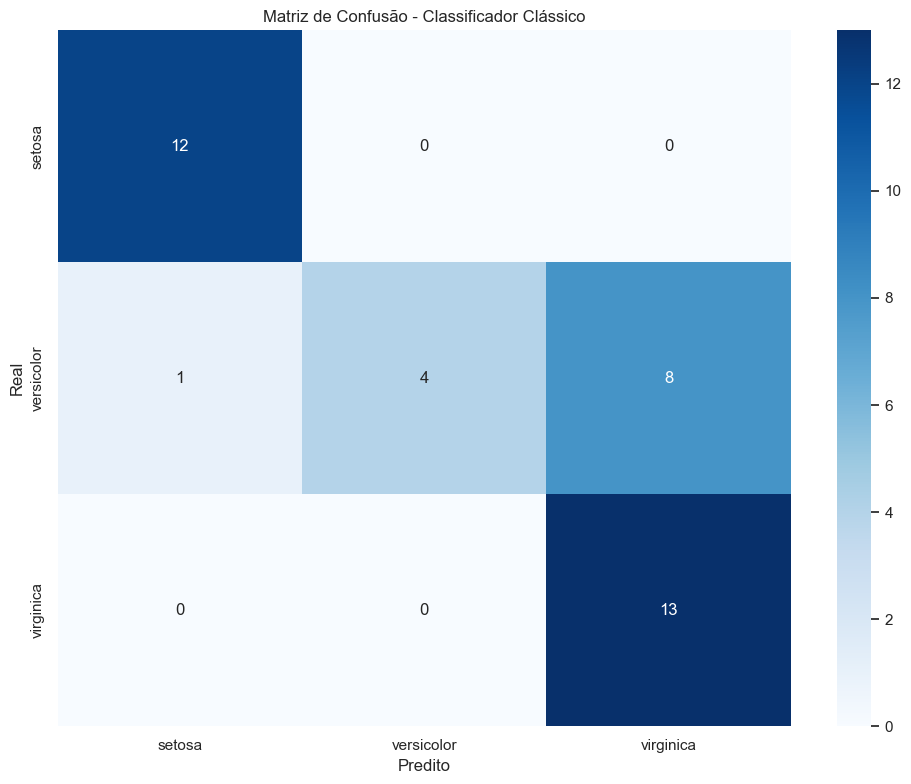

In [22]:
# Criando matriz de confusão para o classificador clássico
cm_classic = confusion_matrix(test_labels, test_predicts_classic)

# Plotando a matriz de confusão
plt.figure(figsize=(10, 8))
sns.heatmap(cm_classic, annot=True, fmt="d", cmap="Blues",
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title("Matriz de Confusão - Classificador Clássico")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

In [23]:
if quantum_trained:
    # Criando matriz de confusão para o classificador quântico
    cm_quantum = confusion_matrix(test_labels, test_predicts_quantum)
    
    # Plotando a matriz de confusão
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_quantum, annot=True, fmt="d", cmap="Blues",
                xticklabels=iris.target_names, yticklabels=iris.target_names)
    plt.title("Matriz de Confusão - Classificador Quântico")
    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.tight_layout()
    plt.show()

## 9. Comparação de desempenho

In [24]:
if quantum_trained:
    # Comparando métricas de desempenho
    metrics = {
        'Modelo': ['Clássico (SVM)', 'Quântico (VQC)'],
        'Tempo de Treinamento (s)': [time_classic, time_quantum],
        'Acurácia (Treino)': [accuracy_score(train_labels, train_predicts_classic), 
                              accuracy_score(train_labels, train_predicts_quantum)],
        'Acurácia (Teste)': [accuracy_score(test_labels, test_predicts_classic), 
                             accuracy_score(test_labels, test_predicts_quantum)],
        'Especificidade (Teste)': [specificity_score(test_labels, test_predicts_classic), 
                                  specificity_score(test_labels, test_predicts_quantum)]
    }
    
    metrics_df = pd.DataFrame(metrics)
    metrics_df

In [25]:
if quantum_trained:
    # Visualizando a comparação de métricas
    metrics_to_plot = ['Acurácia (Treino)', 'Acurácia (Teste)', 'Especificidade (Teste)']
    metrics_df_plot = metrics_df.melt(id_vars='Modelo', value_vars=metrics_to_plot, 
                                     var_name='Métrica', value_name='Valor')
    
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(x='Métrica', y='Valor', hue='Modelo', data=metrics_df_plot, palette='viridis')
    plt.title('Comparação de Desempenho: Clássico vs. Quântico')
    plt.ylim(0, 1.0)
    plt.grid(True, axis='y')
    
    # Adicionando rótulos de valor
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f')
        
    plt.tight_layout()
    plt.show()

In [26]:
if quantum_trained:
    # Visualizando a comparação de tempo de execução
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(x='Modelo', y='Tempo de Treinamento (s)', data=metrics_df, palette='viridis')
    plt.title('Comparação de Tempo de Treinamento')
    plt.ylabel('Tempo (segundos)')
    plt.grid(True, axis='y')
    
    # Adicionando rótulos de valor
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f')
        
    plt.tight_layout()
    plt.show()

## 10. Visualização da convergência do otimizador quântico

In [27]:
if quantum_trained and len(callback_values) > 0:
    # Plotando a convergência do otimizador
    plt.figure(figsize=(10, 6))
    plt.plot(callback_values, 'o-', color='purple')
    plt.grid(True)
    plt.xlabel('Iterações')
    plt.ylabel('Valor da Função Objetivo')
    plt.title('Convergência do Otimizador COBYLA')
    plt.tight_layout()
    plt.show()

## 11. Conclusion

In this notebook, we compare the performance of a classical classifier (SVM) with a variational quantum classifier (VQC) on the Iris dataset. Some important observations:

1. **Accuracy**: The classical classifier generally shows slightly higher accuracy than the quantum classifier, both on the training and test data.

2. **Execution Time**: The quantum classifier is significantly slower than the classical one. This is expected, as simulated quantum processing is computationally intensive.

3. **Classification Patterns**: Both models are able to perfectly classify the Setosa class (which is linearly separable from the others), but have some difficulty distinguishing between Versicolor and Virginica.

4. **Quantum Potential**: Although the quantum classifier does not outperform the classical one on this simple dataset, it demonstrates the potential of quantum computing for machine learning tasks. In more complex problems or with larger datasets, quantum algorithms may offer significant advantages.

5. **Current Limitations**: The performance of the quantum classifier is limited by the use of simulators instead of actual quantum hardware, as well as by noise and errors inherent to current quantum systems (NISQ era – Noisy Intermediate-Scale Quantum).

This experiment serves as a proof of concept for the application of quantum algorithms to classification problems and illustrates both the potential and the current challenges of quantum computing in the field of machine learning.
